# SIMPlex Breast Cancer — extra exploration

Starts from the deposited cross-patient Harmony-integrated object (`SIMPlex_breast_allSamples.rds`). No upstream merge or integration re-run required.


In [ ]:
# DATA_ROOT, HDF5 library, palettes — single source of truth for paths.
source(here::here("config.R"))

In [ ]:
# HDF5 library is loaded by config.R
library(semla)
library(tibble)
library(Seurat)
options(Seurat.object.assay.version = "v5")
library(patchwork)
library(singlet)
library(RcppML)
library(ggplot2)
library(dplyr)
library(tidyr)
library(viridis)
library(pheatmap)
library(cowplot)
library(corrplot)
library(RColorBrewer)
library(heatmap3)
library(harmony)
library(gridExtra)
library(paletteer)
library(Matrix)

### Settings


In [ ]:
rootObj <- paste0(SN_RDS, "/breast_cancer/cross_patient/")
dir.create(wd, recursive = TRUE, showWarnings = FALSE)

colsCelltype <- c("#EAE29CFF", "#6CC382FF", "#E99F69FF", "#CF597EFF", "#EAC17AFF", "#29AD8EFF", "#B2D387FF", "#E4796DFF", "#089392FF")
colsSample <- paletteer_c("grDevices::Dark 3", 10)
colsSubtype <- c("#6EA9B0", "#B1A6D1", "#E18A96")
colsMalignancy <- c("#84D7E1", "#6ABE8C", "#FF95A8")
colsAssays <- c("#6A5ACD", "#FFA500", "#20B2AA")

### Load data

`SIMPlex_breast_allSamples.rds` is ~8 GB. Expect several minutes to load and substantial RAM. Use the **R (simplex renv)** kernel.


In [ ]:
int.all <- readRDS(file.path(rootObj, "SIMPlex_breast_allSamples.rds"))

### Object summary


In [ ]:
int.all

In [ ]:
Assays(int.all)
Reductions(int.all)

In [ ]:
ncol(int.all)
nrow(int.all)

In [ ]:
table(int.all$sample)

In [ ]:
table(int.all$population)
table(int.all$subpopulation)

In [ ]:
head(colnames(int.all@meta.data))

## LR gene sanity check (patient 4 snRNA)
Dot + violin panel for key ligands (CXCL12, C3, THBS2) and receptors (CXCR4, C3AR1, CD47). Saved to `figs/review/LR_sanity_check/`.

In [43]:
# Patient 4 only (same as CellTalker circos)
# pat4_sn <- subset(int.all, subset = sample == "patient4_55um")
# pat4_sn$subpopulation <- gsub("_", "-", pat4_sn$subpopulation)
pat4_sn <- int.all
pat4_sn$subpopulation <- gsub("_", "-", pat4_sn$subpopulation)

# Seurat v5: use log-normalised RNA (not counts, not SCT, not scale.data)
expr_assay <- "RNA"
expr_layer <- "data"
DefaultAssay(pat4_sn) <- expr_assay

pop_cols <- c(
  "iCAF-classical" = "#f6d46c",
  "iCAF-secretory" = "#c4a310",
  "mCAF-classical" = "#800000",
  "mCAF-remodeling" = "#990F02",
  "pDCs" = "#08519C",
  "Plasma-cells" = "#1CA9C9",
  "B-cells-activated" = "#6bd6d4",
  "B/T-mixed-patient4" = "#C6DBEF",
  "Cancer-Transitional-pat4" = "#FF6347",
  "Cancer-Basal/Plastic-pat4" = "#FF9900",
  "Cancer-Basal/Cycl-pat4" = "#B20000"
)

ligand_genes <- c("CXCL12", "C3", "THBS2")
receptor_genes <- c("CXCR4", "C3AR1", "CD47", "NOTCH3")

pat4_lr <- subset(pat4_sn, subset = subpopulation %in% names(pop_cols))
pat4_lr$subpopulation <- factor(pat4_lr$subpopulation, levels = names(pop_cols))
Idents(pat4_lr) <- "subpopulation"

table(pat4_lr$subpopulation)

Warning message:
“Removing 11327 cells missing data for vars requested”



           iCAF-classical            iCAF-secretory            mCAF-classical 
                     1147                       346                      1126 
          mCAF-remodeling                      pDCs              Plasma-cells 
                      248                       288                       662 
        B-cells-activated        B/T-mixed-patient4  Cancer-Transitional-pat4 
                      687                       416                      1498 
Cancer-Basal/Plastic-pat4    Cancer-Basal/Cycl-pat4 
                     2915                       585 

In [44]:
wd_lr <- file.path(FIGS_ROOT, "review", "LR_sanity_check")
dir.create(wd_lr, recursive = TRUE, showWarnings = FALSE)

theme_lr <- theme_bw(base_size = 10) +
  theme(
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, colour = "black"),
    plot.title = element_text(face = "bold", hjust = 0, size = 11),
    legend.title = element_text(size = 9),
    legend.text = element_text(size = 8)
  )

# DotPlot colours expression, not identity — colour population labels on y-axis
style_lr_dotplot <- function(p, pop_cols) {
  pop_labels <- levels(p$data$id)
  p + theme(
    axis.text.y = element_text(
      colour = unname(pop_cols[pop_labels]),
      size = 8,
      face = "bold"
    )
  )
}

# VlnPlot fill uses pop_cols via cols=; also colour population names on x-axis
style_lr_vlnplots <- function(plots, pop_cols) {
  lapply(plots, function(p) {
    pop_labels <- ggplot_build(p)$layout$panel_params[[1]]$x$get_labels()
    p + theme(
      axis.text.x = element_text(
        angle = 45,
        hjust = 1,
        size = 6.5,
        face = "bold",
        colour = unname(pop_cols[pop_labels])
      )
    )
  })
}

In [45]:
p_lig_dot <- style_lr_dotplot(
  DotPlot(
    pat4_lr,
    features = ligand_genes,
    group.by = "subpopulation",
    assay = expr_assay,
    scale = FALSE,
    cols = c("grey92", "#2166AC")
  ) +
    RotatedAxis() +
    labs(title = "Ligands", x = NULL, y = NULL, colour = "Avg expr") +
    theme_lr +
    theme(legend.position = "right"),
  pop_cols
)

p_rec_dot <- style_lr_dotplot(
  DotPlot(
    pat4_lr,
    features = receptor_genes,
    group.by = "subpopulation",
    assay = expr_assay,
    scale = FALSE,
    cols = c("grey92", "#B2182B")
  ) +
    RotatedAxis() +
    labs(title = "Receptors", x = NULL, y = NULL, colour = "Avg expr") +
    theme_lr +
    theme(legend.position = "right"),
  pop_cols
)

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”


In [46]:
vln_lig <- style_lr_vlnplots(
  VlnPlot(
    pat4_lr,
    features = ligand_genes,
    assay = expr_assay,
    layer = expr_layer,
    group.by = "subpopulation",
    cols = pop_cols,
    pt.size = 0,
    combine = FALSE
  ),
  pop_cols
)
p_lig_vln <- wrap_plots(vln_lig, ncol = length(ligand_genes)) +
  plot_annotation(title = "Ligand expression distributions") &
  theme_lr &
  theme(legend.position = "none", axis.title.x = element_blank())

vln_rec <- style_lr_vlnplots(
  VlnPlot(
    pat4_lr,
    features = receptor_genes,
    assay = expr_assay,
    layer = expr_layer,
    group.by = "subpopulation",
    cols = pop_cols,
    pt.size = 0,
    combine = FALSE
  ),
  pop_cols
)
p_rec_vln <- wrap_plots(vln_rec, ncol = length(receptor_genes)) +
  plot_annotation(title = "Receptor expression distributions") &
  theme_lr &
  theme(legend.position = "none", axis.title.x = element_blank())

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
Warning message:
“Vectorized input to `element_text(

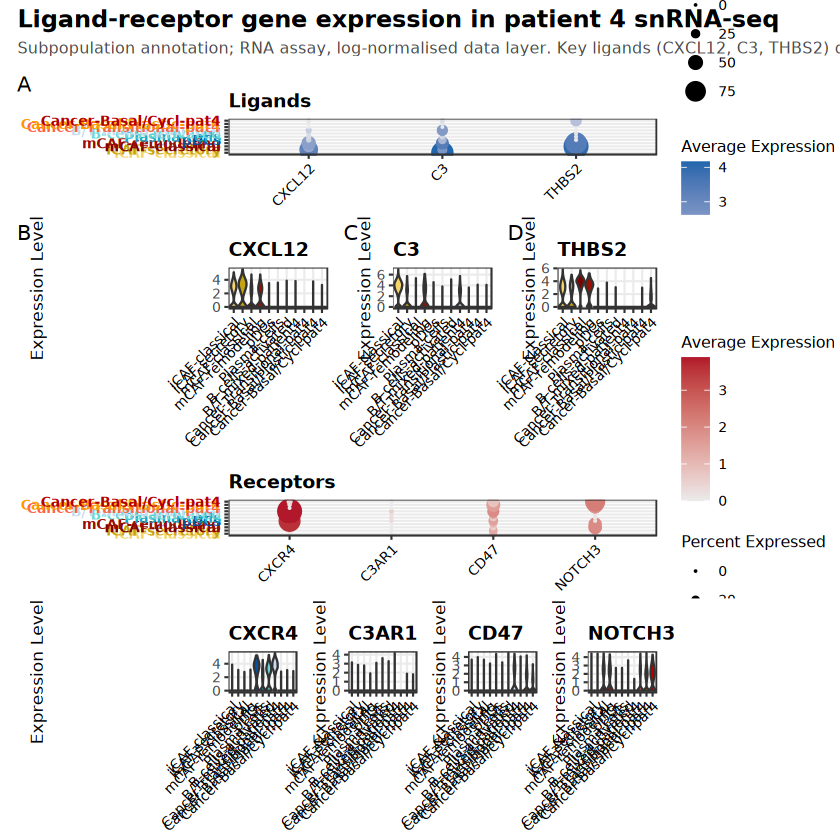

In [47]:
panel_lr <- (p_lig_dot / p_lig_vln / p_rec_dot / p_rec_vln) +
  plot_layout(heights = c(1, 1.15, 1, 1.15)) +
  plot_annotation(
    title = "Ligand-receptor gene expression in patient 4 snRNA-seq",
    subtitle = paste(
      "Subpopulation annotation; RNA assay, log-normalised data layer.",
      "Key ligands (CXCL12, C3, THBS2) detected in iCAF-classical;",
      "receptors (CXCR4, C3AR1, CD47) in pDCs, plasma / activated B cells, and transitional cancer."
    ),
    tag_levels = list(c("A", "B", "C", "D")),
    theme = theme(
      plot.title = element_text(face = "bold", size = 14, hjust = 0),
      plot.subtitle = element_text(size = 9.5, colour = "grey30", hjust = 0, lineheight = 1.15)
    )
  )

panel_lr

ggsave(
  file.path(wd_lr, "LR_snRNA_sanity_check.pdf"),
  plot = panel_lr, width = 14, height = 16, limitsize = FALSE
)
ggsave(
  file.path(wd_lr, "LR_snRNA_sanity_check.png"),
  plot = panel_lr, width = 14, height = 16, dpi = 300, limitsize = FALSE
)